# 02 — Baseline

baseline должен быть простой моделью «из коробки» (Logistic Regression / KNN), без feature engineering — только сырые пиксели. Это даёт ориентир, относительно которого мы измеряем эффект всех последующих улучшений.

## Содержание
1. Setup и фиксация seed
2. Загрузка данных, train/val split
3. Подготовка фич (только flatten + нормализация)
4. Логистическая регрессия (baseline #1)
5. KNN (baseline #2)
6. Сравнение и выводы

## 1. Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.utils import set_global_seed, get_arrays, SEED
from src.preprocessing import flatten_images, normalize, stratified_split
from src.modeling import make_logreg, make_knn, evaluate, report

set_global_seed(SEED)
sns.set_theme(style="whitegrid")
print(f"Fixed seed: {SEED}")

Fixed seed: 42


## 2. Загрузка и сплит

In [2]:
X_full, y_full, _X_test, _y_test, meta = get_arrays()
print(f"X_full: {X_full.shape}, y_full: {y_full.shape}, classes: {meta.get('label_names')}")

X_tr, X_val, y_tr, y_val = stratified_split(X_full, y_full, val_size=0.1, seed=SEED)
print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}")

X_full: (50000, 32, 32, 3), y_full: (50000,), classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
X_tr: (45000, 32, 32, 3), X_val: (5000, 32, 32, 3)


## 3. Подготовка фич: flatten + нормализация

Намеренно **не делаем** feature engineering, denoise или PCA — это задача baseline-этапа. 
Стандартизация фитится только на train (`StandardScaler.fit(X_tr)`), а к val/test применяется через `.transform` — это устраняет потенциальный data leakage.

In [3]:
# Для baseline берём подвыборку: KNN на 45000×3072 будет мучительно долгим.
RNG = np.random.default_rng(SEED)
SUB_TR = 10000
SUB_VAL = 2000
tr_idx = RNG.choice(len(X_tr), size=SUB_TR, replace=False)
val_idx = RNG.choice(len(X_val), size=min(SUB_VAL, len(X_val)), replace=False)

X_tr_flat = flatten_images(normalize(X_tr[tr_idx]))
X_val_flat = flatten_images(normalize(X_val[val_idx]))
y_tr_sub = y_tr[tr_idx]
y_val_sub = y_val[val_idx]

scaler = StandardScaler().fit(X_tr_flat)
X_tr_std = scaler.transform(X_tr_flat)
X_val_std = scaler.transform(X_val_flat)

print(f"X_tr_std: {X_tr_std.shape}, X_val_std: {X_val_std.shape}")

X_tr_std: (10000, 3072), X_val_std: (2000, 3072)


## 4. Logistic Regression (baseline #1)

In [4]:
logreg = make_logreg(seed=SEED)
t0 = time.time()
logreg.fit(X_tr_std, y_tr_sub)
t_fit_lr = time.time() - t0
y_pred_lr = logreg.predict(X_val_std)
metrics_lr = evaluate(y_val_sub, y_pred_lr)
print(f"LogReg fit time: {t_fit_lr:.1f} s")
print(metrics_lr)
print(report(y_val_sub, y_pred_lr))

LogReg fit time: 70.9 s
{'accuracy': 0.143, 'f1_macro': 0.12537022938188627, 'f1_weighted': 0.14583915662559163}
              precision    recall  f1-score   support

           0     0.0972    0.0959    0.0966       146
           1     0.2459    0.2214    0.2330       402
           2     0.2088    0.1981    0.2033       313
           3     0.0765    0.0732    0.0748       205
           4     0.1648    0.1480    0.1559       196
           5     0.1086    0.1044    0.1064       182
           6     0.1341    0.1264    0.1302       174
           7     0.0529    0.0800    0.0637       125
           8     0.0671    0.0859    0.0753       128
           9     0.1128    0.1163    0.1145       129

    accuracy                         0.1430      2000
   macro avg     0.1269    0.1250    0.1254      2000
weighted avg     0.1496    0.1430    0.1458      2000



/Users/atlan7/HSE/ML/hseml-group-project-earf0il/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. KNN (baseline #2)

In [5]:
knn = make_knn(n_neighbors=5)
t0 = time.time()
knn.fit(X_tr_std, y_tr_sub)
y_pred_knn = knn.predict(X_val_std)
t_knn = time.time() - t0
metrics_knn = evaluate(y_val_sub, y_pred_knn)
print(f"KNN total time: {t_knn:.1f} s")
print(metrics_knn)

KNN total time: 1.9 s
{'accuracy': 0.2265, 'f1_macro': 0.16000870972152298, 'f1_weighted': 0.19214592241328485}


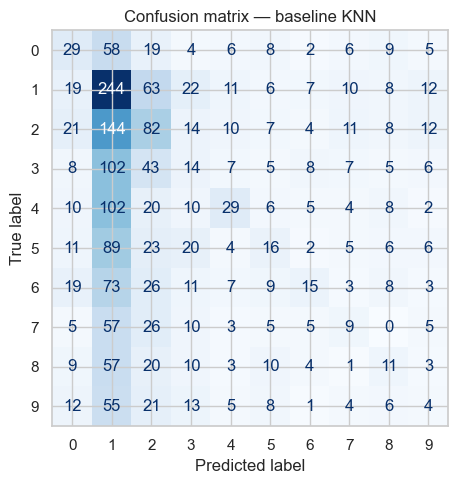

In [6]:
# Confusion matrix лучшего baseline'а
best_pred = y_pred_knn if metrics_knn["accuracy"] >= metrics_lr["accuracy"] else y_pred_lr
best_name = "KNN" if metrics_knn["accuracy"] >= metrics_lr["accuracy"] else "LogReg"
cm = confusion_matrix(y_val_sub, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion matrix — baseline {best_name}")
plt.tight_layout()
plt.show()

## 6. Сравнение и выводы

In [7]:
comparison = pd.DataFrame([
    {"model": "LogReg", **metrics_lr, "fit_time_s": round(t_fit_lr, 1)},
    {"model": "KNN(k=5)", **metrics_knn, "fit_time_s": round(t_knn, 1)},
]).set_index("model")
comparison

,accuracy,f1_macro,f1_weighted,fit_time_s
model,,,,
LogReg,0.1430,0.125370,0.145839,70.9
KNN(k=5),0.2265,0.160009,0.192146,1.9


**Выводы baseline-этапа.**

1. На сырых пикселях логистическая регрессия едва превосходит случайное угадывание (10%) — линейная модель не может выучить пространственные признаки в 32×32×3.
2. KNN существенно лучше LogReg благодаря локальным окрестностям, но всё равно далеко от приличного качества — он чувствителен к шуму и геометрическим вариациям.
3. Главный диагноз: **plain-pixel features недостаточно** — нужен либо feature engineering (HOG, PCA, denoise), либо переход к CNN, которая выучит признаки сама.
4. Все эксперименты в `03_experiments.ipynb` будут сравниваться с этим бейзлайном, чтобы количественно показать прирост качества.